In [20]:
import pyreadstat
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import recall_score, classification_report, confusion_matrix, average_precision_score
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

In [ ]:
# df_ch = pyreadstat.read_sav('/kaggle/input/malnutrition/ch.sav')[0] #Kaggle dataset
df_ch = pyreadstat.read_sav('/workspaces/malnutrition/Dataset/ch.sav')[0] #GitHub Codespace dataset
# df_ch = pyreadstat.read_sav(r"C:\Users\dbastola2022\OneDrive - Florida Atlantic University\Academics\Research\Malnutrition\MICS\malnutrition\Dataset\ch.sav")[0] #Local dataset


# Renaming the columns
df1 = df_ch[['AN4', 'AN8', 'BD2', 'CA1', 'CA14', 'HH6', 'HL4', 'melevel1', 'cinsurance', 'HH7c', 'windex5', 'WAZ2', 'HAZ2', 'WHZ2']]
df1 = df1.rename(columns={
    'AN4': 'child_age',
    'AN8': 'child_weight',
    'BD2': 'ever_breastfed',
    'CA1': 'diarrhoea_last_2_weeks',
    'CA14': 'fever_last_2_weeks',
    'HH6': 'area',
    'HL4': 'child_sex',
    'melevel1': 'mother_education',
    'cinsurance': 'health_insurance',
    'HH7c': 'province',
    'windex5': 'wealth_index',
    'WAZ2': 'underweight',
    'HAZ2': 'stunting',
    'WHZ2': 'wasting'
})

# Remove rows with coded entries in each column
coded_child_age = [99.6, 99.5, 99.4, 99.3]
coded_underweight = [99.99, 99.98, 99.97]
coded_stunting = [99.99, 99.98, 99.97]
coded_wasting = [99.97]
coded_diarrhoea = [9, 8]
coded_fever = [8]
coded_insurance = [9]
coded_breastfed = [9]

df2 = df1.copy()
df2.dropna(inplace=True)

df2 = df2[~df2['child_age'].isin(coded_child_age)]
df2 = df2[~df2['underweight'].isin(coded_underweight)]
df2 = df2[~df2['stunting'].isin(coded_stunting)]
df2 = df2[~df2['wasting'].isin(coded_wasting)] 
df2 = df2[~df2['diarrhoea_last_2_weeks'].isin(coded_diarrhoea)]
df2 = df2[~df2['fever_last_2_weeks'].isin(coded_fever)]
df2 = df2[~df2['health_insurance'].isin(coded_insurance)]
df2 = df2[~df2['ever_breastfed'].isin(coded_breastfed)]

# Convert to Binary Response Variables
df2['underweight'] = [2 if -2 <= x < 2 else 1 for x in df2['underweight']]
df2['stunting'] = [2 if -2 <= x < 2 else 1 for x in df2['stunting']]
df2['wasting'] = [2 if -2 <= x < 2 else 1 for x in df2['wasting']]
df2['malnurished'] = df2[['underweight', 'stunting', 'wasting']].apply(lambda x: 1 if any(i == 1 for i in x) else 0, axis=1)
df2 = df2.drop(['underweight', 'stunting', 'wasting'], axis=1)

# Change binary features from 1/2 to 1/0
df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']] = df2[['ever_breastfed', 'diarrhoea_last_2_weeks', 'fever_last_2_weeks', 'area', 'child_sex', 'health_insurance']].replace({1: 1, 2: 0})

# Standardize continuous column
scaler = StandardScaler()
df2['child_weight'] = scaler.fit_transform(df2[['child_weight']])

# One-hot encode nominal categorical column
df3 = pd.get_dummies(df2, columns=['province'], drop_first=True)

# Convert only boolean dummy columns to 0/1
cols_to_convert = df3.columns.difference(['child_weight'])
df3[cols_to_convert] = df3[cols_to_convert].astype(int)

df3.head(2)

,child_age,child_weight,ever_breastfed,diarrhoea_last_2_weeks,fever_last_2_weeks,area,child_sex,mother_education,health_insurance,wealth_index,malnurished,province_2.0,province_3.0,province_4.0,province_5.0,province_6.0,province_7.0
0,1,-0.617934,1,0,0,0,1,5,0,1,1,0,0,0,0,0,0
2,2,0.797956,1,1,0,0,0,2,0,1,0,0,0,0,0,0,0


### Train-test Split

In [9]:
X = df2.drop(columns=['malnurished'])
y = df2['malnurished']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y, random_state=42)

### Simple model

In [13]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.70      0.70      0.70       397
           1       0.63      0.63      0.63       320

    accuracy                           0.67       717
   macro avg       0.66      0.66      0.66       717
weighted avg       0.67      0.67      0.67       717



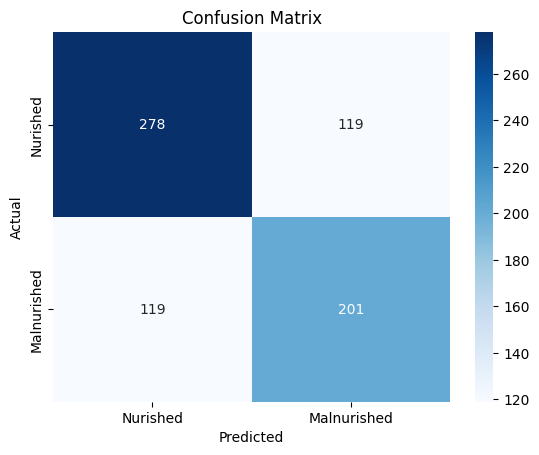

In [15]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Nurished', 'Malnurished'], yticklabels=['Nurished', 'Malnurished'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [19]:
y_probas = rf.predict_proba(X_test)[:, 1]

print(f'Average Precision: {average_precision_score(y_test, y_probas)}')

Average Precision: 0.7007280000832143


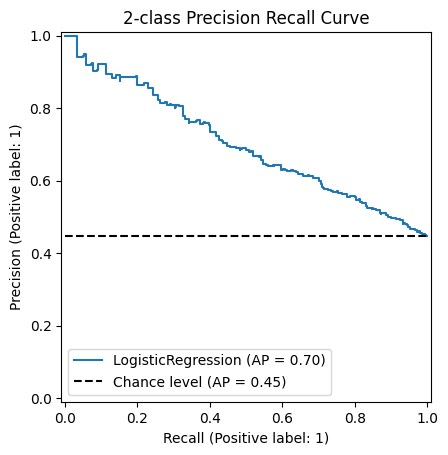

In [21]:
display = PrecisionRecallDisplay.from_estimator(
    rf,
    X_test,
    y_test, 
    name="LogisticRegression",
    plot_chance_level = True,
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()

# Hyperparameter Tuning

In [22]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced'],
    'criterion': ['gini', 'entropy']
}

rf_tune = RandomForestClassifier(random_state=42)

grid_search_rf = GridSearchCV(
    estimator=rf_tune,
    param_grid=param_grid,
    scoring='recall',     
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)


Fitting 5 folds for each of 192 candidates, totalling 960 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'class_weight': [None, 'balanced'], 'criterion': ['gini', 'entropy'], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [26]:
best_rf = grid_search_rf.best_estimator_
y_pred = best_rf.predict(X_test)

print("Best Parameters:", grid_search_rf.best_params_)
print("Best Recall Score (CV):", grid_search_rf.best_score_)
print("Recall on Test Set:", recall_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Best Parameters: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Recall Score (CV): 0.6779074754901961
Recall on Test Set: 0.671875
Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.59      0.64       397
           1       0.57      0.67      0.62       320

    accuracy                           0.63       717
   macro avg       0.63      0.63      0.63       717
weighted avg       0.64      0.63      0.63       717



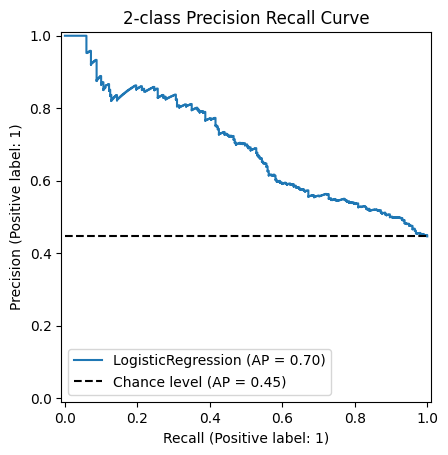

In [27]:
display = PrecisionRecallDisplay.from_estimator(
    best_rf,
    X_test,
    y_test, 
    name="LogisticRegression",
    plot_chance_level = True,
)
display.ax_.set_title('2-class Precision Recall Curve')
plt.show()